<a href="https://colab.research.google.com/github/Tselovanska/machine-learning-course/blob/main/HW_2_1_lin_reg_multiple_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
df = pd.read_csv('cars.csv')
df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


# Завдання 2
В наборі 13 колонок:
- 8 числових
- 2 каиегоріальні (бренд і модель)
- 2 бінарні колонки (тип палива та трансміссія)
- 1 колонка, в яких можна встановити відношення порядку (тип власника)

In [4]:
df.Brand.unique()
# array(['Toyota', 'Honda', 'Ford', 'Maruti', 'Hyundai', 'Tata', 'Mahindra',
#       'Volkswagen', 'Audi', 'BMW', 'Mercedes'], dtype=object)

df.Model.unique()
#array(['Corolla', 'Civic', 'Mustang', 'Swift', 'Sonata', 'Nexon',
#       'Scorpio', 'Polo', 'A4', 'X1', 'C-Class', 'Endeavour', 'Creta',
#       'Harrier', 'Ertiga', 'City', 'Tiguan', 'Q3', '5 Series', 'GLC',
#       'Innova', 'Figo', 'Verna', 'Altroz', 'Thar', 'Passat', 'A6', 'X3',
#       'E-Class', 'Fortuner', 'Aspire', 'Elantra', 'Safari', 'Vitara',
#       'WR-V', 'Ameo', 'A3', '7 Series', 'GLE', 'Yaris', 'Ranger',
#       'Santro', 'Tigor', 'S-Cross', 'BR-V', 'T-Roc', 'Q7', 'X5', 'GLA',
#       'Camry', 'Venue', 'Tiago', 'XUV300', 'Vento', 'A5', '3 Series',
#       'Innova Crysta', 'EcoSport'], dtype=object)

df.Fuel_Type.unique()
#array(['Petrol', 'Diesel'], dtype=object)

df.Transmission.unique()
#array(['Manual', 'Automatic'], dtype=object)

df.Owner_Type.unique()
#array(['First', 'Second', 'Third'], dtype=object)



array(['First', 'Second', 'Third'], dtype=object)

In [5]:
df_test = df[['Brand', 'Model']].drop_duplicates().sort_values(['Brand', 'Model'])
df_test


,Brand,Model
36,Audi,A3
8,Audi,A4
55,Audi,A5
26,Audi,A6
17,Audi,Q3
46,Audi,Q7
56,BMW,3 Series
18,BMW,5 Series
37,BMW,7 Series
9,BMW,X1


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

# Завдання 3

In [6]:
cat_cols = ['Car_ID',	'Brand',	'Model',	'Year',	'Kilometers_Driven',	'Fuel_Type',	'Transmission',	'Owner_Type',	'Mileage',	'Engine',	'Power',	'Seats']

inputs = df[cat_cols]
targets = df.Price
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

In [7]:
X_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,7
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,5


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

# Завдання 4

<Axes: xlabel='Fuel_Type', ylabel='Price'>

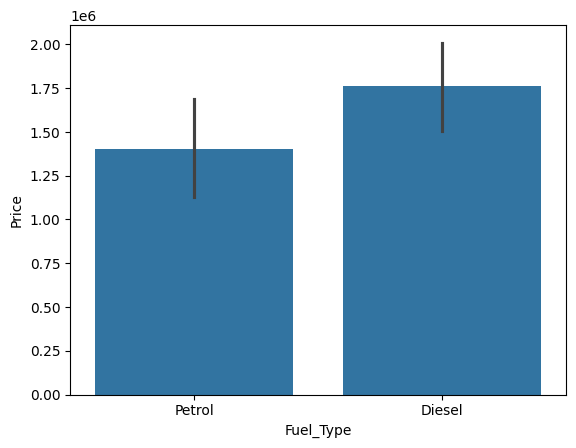

In [8]:
sns.barplot(data=df, x='Fuel_Type', y='Price')

In [9]:
fuel_type_code = {'Diesel': 1, 'Petrol': 0}
X_train['fuel_type_code'] = X_train.Fuel_Type.map(fuel_type_code)
X_train.fuel_type_code


,fuel_type_code
83,0
55,1
26,0
54,0
19,0
...,...
3,1
2,0
6,1
27,1


<Axes: xlabel='Transmission', ylabel='Price'>

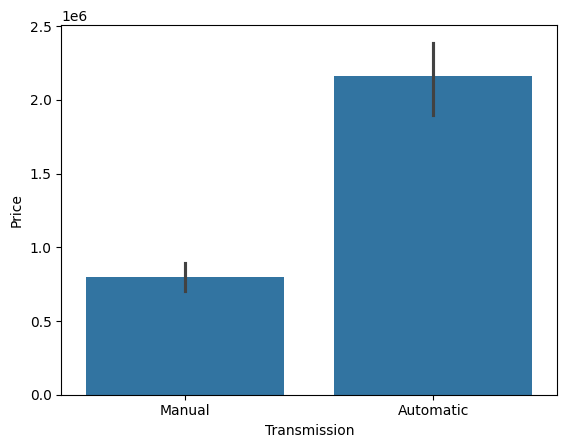

In [10]:
sns.barplot(data=df, x='Transmission', y='Price')

In [11]:
transmission_code = {'Automatic': 1, 'Manual': 0}
X_train['transmission_code'] = X_train.Transmission.map(transmission_code)
X_train.transmission_code

,transmission_code
83,1
55,1
26,1
54,0
19,1
...,...
3,0
2,1
6,1
27,1


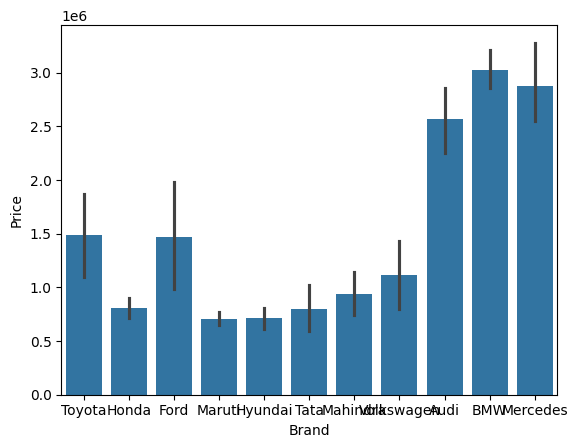

In [12]:
#Закодуйте колонку Brand з використанням sklearn.preprocessing.
#OneHotEncoder аналогічно до того, як ми робили це в лекції. Увага!
#Ми робимо виклик методу Encoder.fit() на тренувальних даних X_train,
#а на тестувальних тільки викликаємо Encoder.transform().
#Додайте закодовані значення в набори даних X_train, X_test.
sns.barplot(data=df, x='Brand', y='Price')

enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])

one_hot = enc.transform(X_train[['Brand']]).toarray()

X_train[enc.categories_[0]] = one_hot

X_test[enc.categories_[0]] = enc.transform(X_test[['Brand']]).toarray()

In [13]:
body_type = {
    # Hatchback
    'Swift': 'Hatchback', 'Polo': 'Hatchback', 'Tiago': 'Hatchback', 'Figo': 'Hatchback',
    'Santro': 'Hatchback', 'Ameo': 'Hatchback', 'Aspire': 'Hatchback', 'Altroz': 'Hatchback',
    'WR-V': 'Hatchback', 'BR-V': 'Hatchback', 'Yaris': 'Hatchback', 'Verna': 'Hatchback',
    'Tigor': 'Hatchback', 'S-Cross': 'Hatchback', 'A3': 'Hatchback',
    # Sedan
    'A4': 'Sedan', 'A5': 'Sedan', 'A6': 'Sedan', '3 Series': 'Sedan', '5 Series': 'Sedan',
    '7 Series': 'Sedan', 'City': 'Sedan', 'Civic': 'Sedan', 'Camry': 'Sedan', 'Corolla': 'Sedan',
    'Elantra': 'Sedan', 'Sonata': 'Sedan', 'C-Class': 'Sedan', 'E-Class': 'Sedan',
    'Passat': 'Sedan', 'Vento': 'Sedan', 'Mustang': 'Sedan',
    # SUV
    'Q3': 'SUV', 'Q7': 'SUV', 'X1': 'SUV', 'X3': 'SUV', 'X5': 'SUV', 'Creta': 'SUV', 'Venue': 'SUV',
    'Scorpio': 'SUV', 'Thar': 'SUV', 'XUV300': 'SUV', 'Vitara': 'SUV', 'GLA': 'SUV', 'GLC': 'SUV',
    'GLE': 'SUV', 'Harrier': 'SUV', 'Nexon': 'SUV', 'Safari': 'SUV', 'EcoSport': 'SUV',
    'Endeavour': 'SUV', 'Fortuner': 'SUV', 'T-Roc': 'SUV', 'Tiguan': 'SUV', 'Ranger': 'SUV',
    'Ertiga': 'SUV', 'Innova': 'SUV', 'Innova Crysta': 'SUV',
}

X_train['body_type'] = X_train.Model.map(body_type)
X_train.body_type

,body_type
83,SUV
55,Sedan
26,Sedan
54,Sedan
19,SUV
...,...
3,Hatchback
2,Sedan
6,SUV
27,SUV


In [14]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [15]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,body_type,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SUV,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sedan,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,SUV,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [16]:
X_train_numbers = pd.concat([X_train.select_dtypes(np.number), y_train], axis=1)
X_train_numbers

X_test['fuel_type_code'] = X_test.Fuel_Type.map(fuel_type_code)
X_test['transmission_code'] = X_test.Transmission.map(transmission_code)

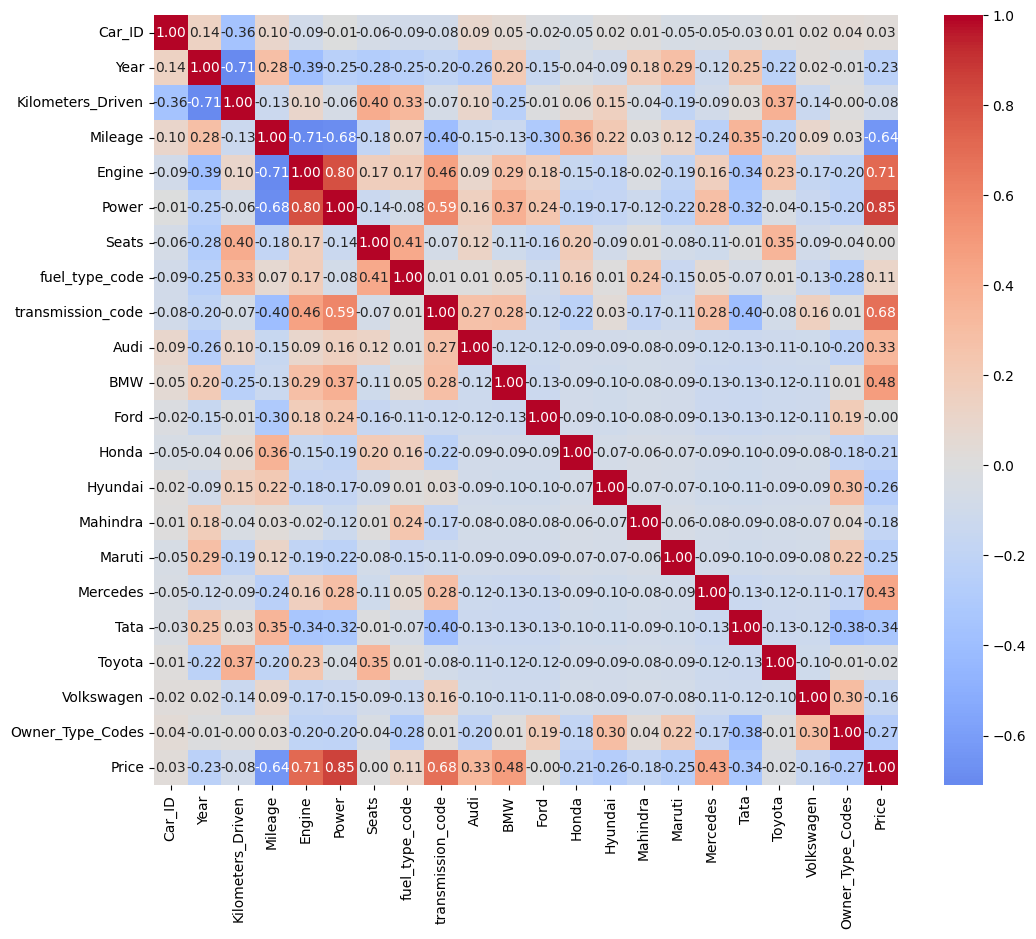

,Price
Price,1.000000
Power,0.849137
Engine,0.710561
transmission_code,0.680731
Mileage,0.638404
BMW,0.477522
Mercedes,0.431606
Tata,0.341815
Audi,0.328858
Owner_Type_Codes,0.265537


In [17]:
correlation_matrix = X_train_numbers.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

correlation_matrix['Price'].abs().sort_values(ascending=False)

# Завдання 5
Power	0.849137

Engine	0.710561

transmission_code	0.680731

Mileage	0.638404



**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [18]:
# прибрала Car_ID адже фактично це порядковий номер, він не має мати коефіцієнту
inputs, target = X_train[['Year',	'Kilometers_Driven',	'Mileage',	'Engine',	'Power',	'Seats',	'fuel_type_code',	'transmission_code',	'Audi',	'BMW',	'Ford',	'Honda',	'Hyundai',	'Mahindra',	'Maruti',	'Mercedes',	'Tata',	'Toyota',	'Volkswagen',	'Owner_Type_Codes']], y_train

model = LinearRegression().fit(inputs, target)

prediction = model.predict(inputs)

inputs_test = X_test[['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power',
                       'Seats', 'fuel_type_code', 'transmission_code', 'Audi', 'BMW', 'Ford',
                       'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Toyota',
                       'Volkswagen', 'Owner_Type_Codes']]
prediction_test = model.predict(inputs_test)

loss_train = root_mean_squared_error(target, prediction)
loss_test = root_mean_squared_error(y_test, prediction_test)

print(f'RMSE train: {loss_train:.2f}')
print(f'RMSE test: {loss_test:.2f}')

RMSE train: 210342.80
RMSE test: 259601.27


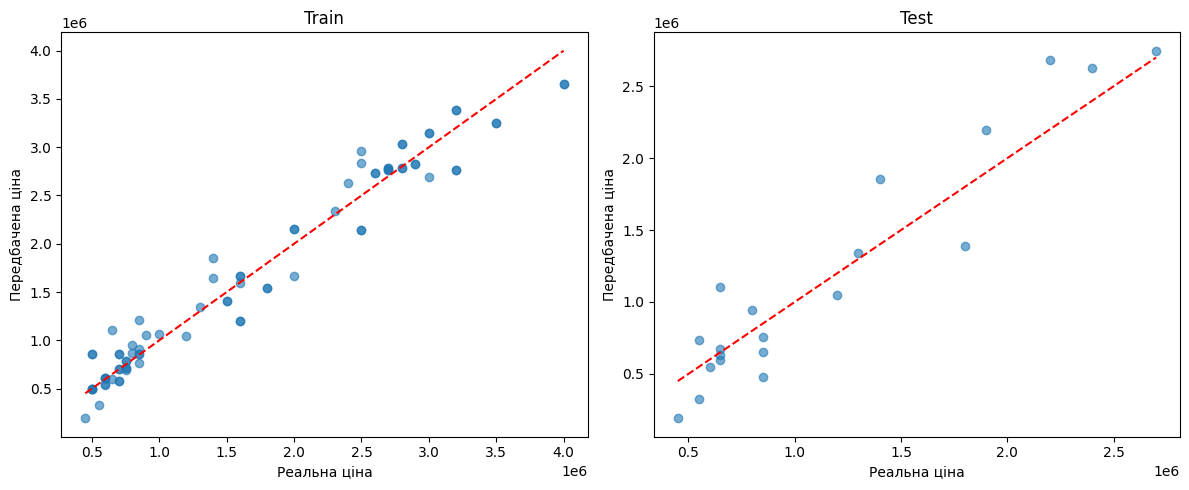

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(target, prediction, alpha=0.6)
plt.plot([target.min(), target.max()], [target.min(), target.max()], 'r--')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.title('Train')

plt.subplot(1, 2, 2)
plt.scatter(y_test, prediction_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальна ціна')
plt.ylabel('Передбачена ціна')
plt.title('Test')

plt.tight_layout()
plt.show()

# Завдання 6
Модель гірше узагальнює на нових даних порівняно з тестовими.
Test RMSE (258 182) is ~23% вищий за train (210 294).

Модель потребує доопрацювання.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [20]:
scaler = StandardScaler().fit(inputs)
scaled_train = scaler.transform(inputs)
scaled_test = scaler.transform(inputs_test)

scaled_model = LinearRegression().fit(scaled_train, target)

coef_df =pd.DataFrame({
    'feature': inputs.columns,
    'coefficient': scaled_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

              feature    coefficient
4               Power  500000.506765
15           Mercedes  209257.737636
9                 BMW  208105.079738
8                Audi  206123.092108
6      fuel_type_code  185245.840763
12            Hyundai -151916.052473
13           Mahindra -140931.632855
2             Mileage -131884.633123
10               Ford -119069.155830
7   transmission_code  115153.439599
14             Maruti -112786.673613
1   Kilometers_Driven  -99713.958682
18         Volkswagen  -93391.358093
16               Tata  -65558.490423
11              Honda  -63112.339850
19   Owner_Type_Codes   43335.066079
3              Engine  -24683.084080
17             Toyota   17619.429555
0                Year  -11604.260975
5               Seats   -1744.048812


# Завдання 7
Топ фактори: Power, Mercedes, BMW, Audi, fuel_type_code.

Негативний вплив: Hyundai, Mahindra, Mileage, Ford.

Мінімальний вплив: Seats, Year, кандидати на виключення.

Так, вплив логічний, потужніть, преміальні бренди та тип палива - впливають на вартість машини. При тому, дешевші моделі навпаки зменшують ціну.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [21]:
scaled_train_df = pd.DataFrame(scaled_train, columns=inputs.columns, index=inputs.index)

Y = target
X = scaled_train_df

X = sm.add_constant(X)
model_sm = sm.OLS(Y,X).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     73.14
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           2.34e-34
Time:                        08:05:21   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      60   BIC:                             2276.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

# Завдання 8
Список значущих ознак (p<0.05)
Power, Mileage, fuel_type_code, transmission_code, Audi, BMW, Ford, Hyundai, Mahindra, Maruti, Mercedes, Volkswagen

Незначущі: Year, Kilometers_Driven, Engine, Seats, Honda, Tata, Toyota, Owner_Type_Codes

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [22]:
scaled_train_df_signif = scaled_train_df[['Power', 'Mileage', 'fuel_type_code', 'transmission_code', 'Audi', 'BMW', 'Ford', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Volkswagen' ]]

In [23]:
Y = target
X_signif = scaled_train_df_signif

X_signif = sm.add_constant(X_signif)
model_sm = sm.OLS(Y,X_signif).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           4.12e-39
Time:                        08:05:21   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

# Завдання 9
Rsqr і Adj. Rsqr практично не змінились (падіння <1%).

8 видалених ознак (Year, Kilometers_Driven, Engine, Seats, Honda, Tata, Toyota, Owner_Type_Codes) несли мінімальну пояснювальну цінність.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [24]:
scaled_train_df_025 = scaled_train_df[['Kilometers_Driven', 'Mileage', 'Power', 'fuel_type_code', 'transmission_code', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Volkswagen']]


In [25]:
Y = target
X_025 = scaled_train_df_025

X_025 = sm.add_constant(X_025)
model_sm = sm.OLS(Y,X_025).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 05 Jul 2026   Prob (F-statistic):           4.85e-38
Time:                        08:05:21   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

# Завдання 10
Adj Rsqr --> AIC

З 8 -> 0.946 --> 2228

З 9 -> 0.943 --> 2227

З 10 -> 0.948 --> 2221

М'якший підхід до критерій вибору покращив покриття моделі (Adj. Rsqr) і при цьому ми отримали точніший AIC --> цей варіант є найбільш оптимальним для вирішення цієї задачі.